In [1]:
import numpy as np
import matplotlib.pyplot as plt

units = np.load('../Data/units.npy',allow_pickle=True)
# reaction time
reaction = np.load('../Data/reaction.npy',allow_pickle=True)
letters  = np.load('../Data/letters_sep.npy',allow_pickle=True)
probes   = np.load('../Data/probes_sep.npy',allow_pickle=True)
uniqueLetters = np.array([p for p in np.unique(np.concatenate(letters)) if p not in ['Q', 'W', 'X']])
print(uniqueLetters)

setsize  = [
           np.array([np.sum([1 if u in letterString else 0 for u in uniqueLetters]) for letterString in ls],dtype=int)
           for ls in letters]

subj = np.load('../Data/subjs_sep.npy',allow_pickle=True)
subj = [s[0] for s in subj]
info = np.load('../Data/trial_corrInfo.npy',allow_pickle=True)

['B' 'C' 'D' 'F' 'G' 'H' 'K' 'L' 'N' 'P' 'R' 'S' 'T' 'V' 'Z']


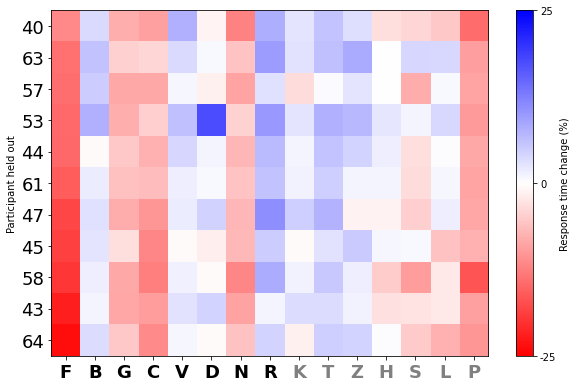

In [2]:
import numpy as np

uniqueSub  = np.unique(subj)
sub_list   = list(uniqueSub) + [0]   # leave-one-out + no-0 baseline
n_letters  = len(uniqueLetters)      # should be 15

all_m = {}   # stores m for each subOut
L = 15
# ----------------------------------------------------------
# FUNCTION: compute m vector for one subOut
# ----------------------------------------------------------
def compute_m_for_subout(subOut):

    setREF  = [4, 6, 8]
    respREF = [52]

    # -----------------------------
    # First condition: respREF = [52]
    # -----------------------------
    corr_letter_all = []
    for u in uniqueLetters:
        corr_letter = []
        for s in np.unique(subj):
            if s != subOut:

                mask       = np.where(subj == s)[0]
                probe_subj = np.concatenate(probes[mask], axis=0)
                info_cat   = np.concatenate(info[mask], axis=0)

                corr_subj  = info_cat[:, -1]
                corr_subj  = corr_subj[np.where(np.logical_and(
                    np.logical_and(info_cat[:, 1],
                                   [m in respREF for m in info_cat[:, 3]]),
                    [m in setREF  for m in info_cat[:, 0]])
                )[0]]

                resp  = info_cat[info_cat[:,1] == True, 3]
                setR  = info_cat[info_cat[:,1] == True, 0]

                probe_subj = probe_subj[
                    np.logical_and([r in respREF for r in resp],
                                   [r in setREF  for r in setR])
                ]
                mask_u = np.where(probe_subj == u)[0]
                corr_letter.extend(corr_subj[mask_u])

        corr_letter_all.append(corr_letter)

    corr_letter_all = np.array(corr_letter_all, dtype=object)

    # median correlation for respREF = [52]
    m52 = [np.median(corr_letter_all[i]) for i in range(n_letters)]

    # ----------------------------------------------------------
    # Second condition: respREF = [51]
    # ----------------------------------------------------------
    respREF = [51]
    corr_letter_all = []
    for u in uniqueLetters:
        corr_letter = []
        for s in np.unique(subj):
            if s != subOut:

                mask       = np.where(subj == s)[0]
                probe_subj = np.concatenate(probes[mask], axis=0)
                info_cat   = np.concatenate(info[mask], axis=0)

                corr_subj  = info_cat[:, -1]
                corr_subj  = corr_subj[np.where(np.logical_and(
                    np.logical_and(info_cat[:, 1],
                                   [m in respREF for m in info_cat[:, 3]]),
                    [m in setREF  for m in info_cat[:, 0]])
                )[0]]

                resp  = info_cat[info_cat[:,1] == True, 3]
                setR  = info_cat[info_cat[:,1] == True, 0]

                probe_subj = probe_subj[
                    np.logical_and([r in respREF for r in resp],
                                   [r in setREF  for r in setR])
                ]
                mask_u = np.where(probe_subj == u)[0]
                corr_letter.extend(corr_subj[mask_u])

        corr_letter_all.append(corr_letter)

    corr_letter_all = np.array(corr_letter_all, dtype=object)

    # median correlation for respREF = [51]
    m51 = [np.median(corr_letter_all[i]) for i in range(n_letters)]

    # ----------------------------------------------------------
    # Final m vector (fractional response-time change)
    # ----------------------------------------------------------
    m = (np.array(m51) - np.array(m52)) / np.array(m52)

    return m


# ----------------------------------------------------------
# Compute m for all subOut values
# ----------------------------------------------------------
for subOut in sub_list:
    all_m[subOut] = compute_m_for_subout(subOut)


# ----------------------------------------------------------
# Build percentual change matrix relative to the no-subject-removed baseline
# ----------------------------------------------------------
m_no0 = all_m[0]   # baseline vector

change_matrix = np.zeros((len(sub_list), n_letters))
row_labels    = []

for i, subOut in enumerate(sub_list):

    if subOut == 0:
        change_matrix[i, :] = 0
        row_labels.append("no0")
    else:
        change_matrix[i, :] = all_m[subOut] #((all_m[subOut] - m_no0)/np.abs(m_no0))
        row_labels.append(f"no{subOut}")

# -----------------------------------------------------------
# 1) Compute GLOBAL letter ordering
# -----------------------------------------------------------
global_letter_acc = []
T1 = 2
T2 = 16
T = T2-T1
for k in range(50):
    al = []
    all_L = np.load(f'../single_letter_{k}.npy')
    for letter_index in range(L):
        al.append(np.diag(all_L[letter_index]))
    al = np.array(al)
    global_letter_acc.append(al)

global_letter_acc = np.array(global_letter_acc)  # shape: (50, L, n_times)

# Compute global last-step accuracy like your code
global_last = np.array([
    np.cumsum(global_letter_acc[:, i, T1:T2], axis=-1)[:, -1] / T
    for i in range(L)
])  # shape: (L, 50)

# Mean global decoding accuracy per letter                     ### NEW
global_mean_per_letter = np.median(global_last, axis=1)          # shape: (L,)  ### NEW

# Sorting order (descending)
sort_idx = np.argsort(np.median(global_last, axis=1))[::-1]
#sort_idx = np.argsort(m_no0)

# -----------------------------------------------------------
# 5) Plot heatmap of percentage point difference
# -----------------------------------------------------------
L = 15
change_matrix = change_matrix[:-1, sort_idx]  # same as before

sortF = np.argsort(change_matrix[:,0])[::-1]

# If you want to plot ranks instead of raw changes:
change_2 = change_matrix[sortF] #rank_matrix

plt.rcParams.update({'font.size': 22})
fig, ax = plt.subplots(figsize=(1 + L * 0.5, 1.1 + len(uniqueSub) * 0.4))

sorted_letters = uniqueLetters[sort_idx]
im = ax.imshow(change_2, aspect='auto', cmap='bwr_r',vmin=-0.25,vmax=0.25)

# (Optional) you might still want this based on raw changes, not ranks:
fano_per_letter = np.mean(np.abs(change_matrix), axis=0)

ax.set_xticks(np.arange(L))
ax.set_xticklabels(sorted_letters, rotation=0, fontsize=18)

ax.set_yticks(np.arange(len(uniqueSub)))
#ax.set_yticklabels(np.arange(1,len(uniqueSub)+1), fontsize=18)
ax.set_yticklabels(uniqueSub[sortF], fontsize=18)

ax.set_ylabel('Participant held out')

cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Response time change (%)')
cbar.set_ticks([-0.25, 0, 0.25])          # numeric tick positions
cbar.set_ticklabels(['-25', '0', '25']) # what to display

setLETTER = ['F','B','C','G','V','D','N','R']
# Make selected letters bold black, others bold gray
for tick, letter in zip(ax.get_xticklabels(), sorted_letters):
    if letter in setLETTER:
        tick.set_color('black')
    else:
        tick.set_color('gray')
    tick.set_fontweight('bold')

plt.tight_layout()
plt.savefig('resp_subj2_idx.png', dpi=200)
plt.show()

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import kendalltau

# --------------------------------------------------------
# 1. Compute observed tau values and their median
# --------------------------------------------------------
observed_taus = np.array([
    kendalltau(m_no0[sort_idx], change_2[pp])[0]
    for pp in range(len(change_2))
])

observed_median = np.median(observed_taus)

# --------------------------------------------------------
# 2. Build permutation-null distribution of medians
# --------------------------------------------------------
n_perm = 5000
perm_medians = np.zeros(n_perm)

for i in range(n_perm):
    # permute each row/entry of change_2 independently
    perm_change = np.array([
        np.random.permutation(change_2[pp])
        for pp in range(len(change_2))
    ])
    
    perm_taus = np.array([
        kendalltau(m_no0[sort_idx], perm_change[pp])[0]
        for pp in range(len(change_2))
    ])
    
    perm_medians[i] = np.median(perm_taus)

In [4]:
observed_median

0.7714285714285715

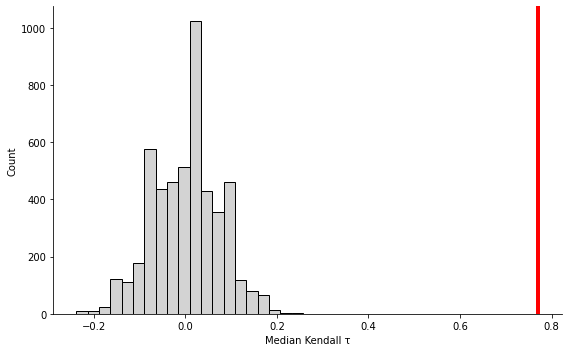

In [5]:
# --------------------------------------------------------
# 3. Plot histogram + red median line
# --------------------------------------------------------
fig,ax = plt.subplots(figsize=(8,5))
plt.hist(perm_medians, bins=20, color='lightgray', edgecolor='black')
plt.axvline(observed_median, color='red', linewidth=4, label=f'Observed median = {observed_median:.3f}')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.xlabel("Median Kendall τ")
plt.ylabel("Count")
plt.tight_layout()
plt.show()